# Forecasting Access & Usage, 2025–2027 (Task 4)

**Author:** Yostina Abera  
**Targets:** `ACC_OWNERSHIP` (account ownership, % adults) and `USG_DIGITAL_PAY` (made/received a digital payment, % adults).  
**Engine:** `src/forecast.py` (builds on the Task-3 impact model). Interpretation: `reports/forecast_interpretation.md`.

The data is sparse (account ownership has **4 Findex points over 13 years**; digital payments have **one**). So we combine three methods: a linear trend with a prediction interval (statistical uncertainty), an **event-augmented scenario** model (the central forecast), and a scenario band (structural uncertainty).

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd, numpy as np
%matplotlib inline
from src import forecast as fc
pd.set_option('display.width', 200)

## 1. Targets and available history
Account ownership has a usable trend; digital payments do not — a limitation we carry throughout.

In [2]:
own = fc.ownership_series()
print('ACC_OWNERSHIP history:'); print(own.to_string(index=False))
print(f'\nUSG_DIGITAL_PAY: single point = {fc.DP_ANCHOR}% (2024); '
      f'implied payment-propensity = {fc.DP_PROPENSITY_0:.3f} of account-holders')

ACC_OWNERSHIP history:
 year  value
 2014   22.0
 2017   35.0
 2021   46.0
 2024   49.0

USG_DIGITAL_PAY: single point = 21.0% (2024); implied payment-propensity = 0.429 of account-holders


## 2. Method 1 — linear trend continuation (+ 95% prediction interval)
Ordinary least squares on the 4 points, with a t-based prediction interval (2 d.f.). Honest, but it **ignores the observed deceleration** (+13, +11, +3 pp between surveys) so it tends to over-forecast; the interval is very wide because n=4.

In [3]:
lin, params = fc.linear_trend(own)
print(f"slope = {params['slope']:.2f} pp/yr,  residual s = {params['resid_std']:.2f}")
lin.round(1)

slope = 2.71 pp/yr,  residual s = 3.54


,year,value,lo,hi
0,2025,54.2,33.4,75.1
1,2026,56.9,34.9,79.0
2,2027,59.7,36.3,83.0


## 3. Method 2 — event-augmented scenario model (central forecast)
Anchor at the 2024 observation and add (a) an **organic drift** (non-event pp/yr) and (b) **attenuated event effects** from the Task-3 impact model (`simulate_indicator`). Scenarios vary the drift and the event attenuation α:

| scenario | organic drift | event α | rationale |
|---|---|---|---|
| pessimistic | 0.5 pp/yr | 0.10 | the 2021–24 near-stall continues |
| base | 1.2 pp/yr | 0.18 | ≈ recent rate; α = Task-3 validated value |
| optimistic | 2.0 pp/yr | 0.30 | device adoption + events accelerate |


In [4]:
own_scen = fc.ownership_scenarios()
own_scen.round(1)

,pessimistic,base,optimistic
2025,50.0,51.1,52.5
2026,50.8,52.8,55.4
2027,51.5,54.4,57.9


## 4. Method 3 — digital payments as ownership × payment-propensity
With only one Findex point, we project digital payments as `ownership × propensity`, where propensity (share of account-holders paying digitally, 0.43 in 2024) is the scenario lever. Rising propensity is corroborated by **P2P transactions +158% YoY** (49.7M→128.3M) and the interoperability events (EthioPay, M-Pesa–EthSwitch).

In [5]:
dp_scen = fc.digital_pay_scenarios()
dp_scen.round(1)

,pessimistic,base,optimistic
2025,21.7,23.0,24.7
2026,22.3,24.8,28.2
2027,22.9,26.6,31.9


## 5. Forecast table with confidence intervals
`base` is the central forecast; `[pessimistic, optimistic]` is the scenario band; for ownership the linear 95% PI is shown alongside. Saved to `data/processed/forecasts_2025_2027.csv`.

In [6]:
table = fc.save_table()
table

saved data/processed/forecasts_2025_2027.csv


,target,year,base,pessimistic,optimistic,linear_trend,linear_lo95,linear_hi95
0,ACC_OWNERSHIP,2025,51.1,50.0,52.5,54.2,33.4,75.1
1,ACC_OWNERSHIP,2026,52.8,50.8,55.4,56.9,34.9,79.0
2,ACC_OWNERSHIP,2027,54.4,51.5,57.9,59.7,36.3,83.0
3,USG_DIGITAL_PAY,2025,23.0,21.7,24.7,NaN,NaN,NaN
4,USG_DIGITAL_PAY,2026,24.8,22.3,28.2,NaN,NaN,NaN
5,USG_DIGITAL_PAY,2027,26.6,22.9,31.9,NaN,NaN,NaN


## 6. Scenario visualizations

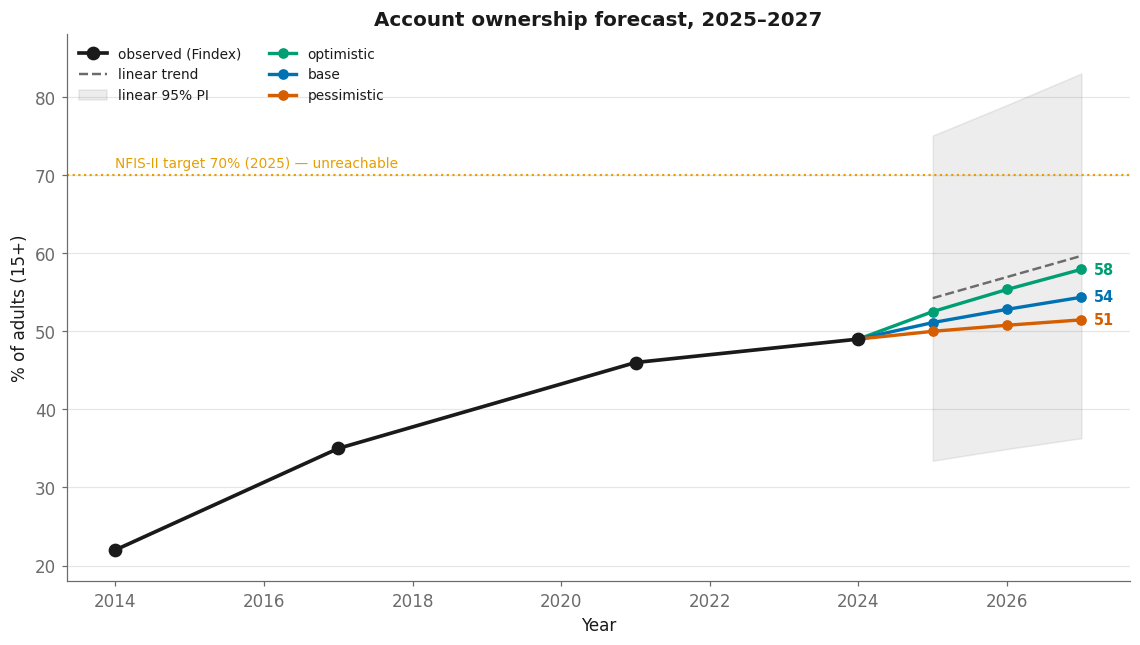

In [7]:
_ = fc.fig_ownership_forecast()

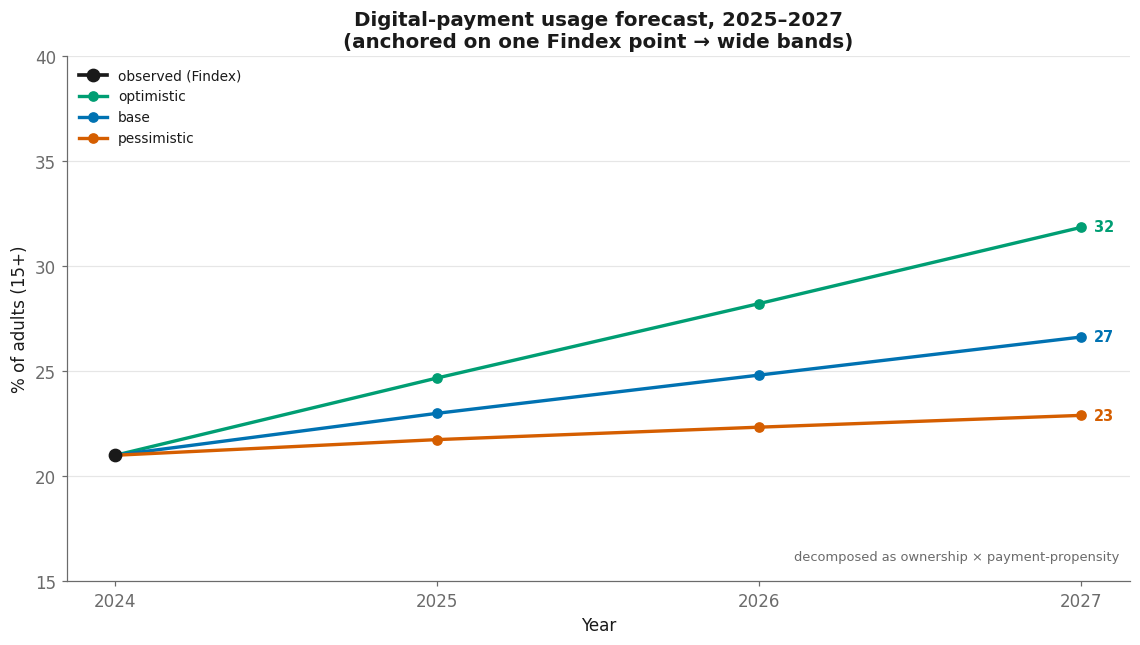

In [8]:
_ = fc.fig_digital_pay_forecast()

## 7. Interpretation
Full write-up: `reports/forecast_interpretation.md`.

**What the model predicts.** Account ownership reaches **~54% by 2027** (base; band 51–58%), continuing the *deceleration* — not the linear extrapolation to ~60%. Digital payments grow faster off a low base to **~27% by 2027** (base; band 23–32%), because the usage frontier (transacting) is moving even though the access frontier (owning an account) has largely saturated.

**The NFIS-II 70% ownership target (2025) is unreachable** — it would require +21pp in a year against an observed +1pp/yr. Even the optimistic path is ~58% by 2027.

**Events with the largest potential impact.** On *usage*: interoperability (EthioPay, M-Pesa–EthSwitch) and the digital-payments strategy — they raise payment propensity. On *access*: Fayda digital ID and (long-lag) foreign-bank entry — but their ownership effect is attenuated (α≈0.18) because, as Task 3 showed, new rails mostly digitise the already-banked rather than create new account-holders.

**Key uncertainties.** (1) Digital payments rest on a single data point — the widest band. (2) The attenuation α is calibrated on one interval. (3) Long-lag policies (foreign banks, NFIS-II) are not yet observable. (4) The binding constraint is demand-side device access (phone 41%, smartphone 40%); if that gap does not close, even the base ownership path is optimistic.